In [ ]:
# Grwtech Financial KPI Analysis

## Project Objective
Analyze the financial and customer performance of Grwtech a fictional SaaS startup.

## Key Metrics
-Revenue
- Expenses
- Burn Rate
- Customer Growth
- CAC
- ARPU
- LTV
- LTV:CAC
- Run Rate
- Cohort Retention

## Tools
- Python
- Pandas
- NumPy
- Matplotlib

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
file_path = "financial data.xlsx"
excel_data = pd.ExcelFile(file_path)
print(excel_data.sheet_names)

['customers', 'revenue', 'expenses', 'marketing', 'KPI_cal', 'cohort analysis']


In [11]:
customers = pd.read_excel(file_path, sheet_name="customers")
revenue = pd.read_excel(file_path, sheet_name="revenue")
expenses = pd.read_excel(file_path, sheet_name="expenses")
marketing = pd.read_excel(file_path, sheet_name="marketing")
kpi = pd.read_excel(file_path, sheet_name="KPI_cal")
cohort = pd.read_excel(file_path, sheet_name="cohort analysis")

In [12]:
print("Customers:", customers.shape)
print("Revenue:", revenue.shape)
print("Expenses:", expenses.shape)
print("Marketing:", marketing.shape)
print("KPI:", kpi.shape)
print("Cohort:", cohort.shape)

Customers: (115, 7)
Revenue: (12, 5)
Expenses: (12, 7)
Marketing: (12, 7)
KPI: (12, 12)
Cohort: (12, 13)


In [13]:
customers.head()

,Customer_ID,Acquisition_Date,Acquisition_Channel,Monthly_Revenue,Status,Churn_Date,Cohort_Month
0,C001,2025-01-05,Google Ads,2000,Active,NaT,2025-01-01
1,C002,2025-01-08,Referral,3000,Active,NaT,2025-01-01
2,C003,2025-01-12,LinkedIn,2500,NaN,2025-04-20,2025-01-01
3,C004,2025-01-18,Organic,1800,Active,NaT,2025-01-01
4,C005,2025-01-25,Meta Ads,2200,Active,NaT,2025-01-01


In [14]:
revenue.head()

,Month,New Customers,Active Customers,Monthly Revenue,Growth
0,2025-01-01,35,35,175000,NaN
1,2025-02-01,42,72,360000,1.057143
2,2025-03-01,48,111,555000,0.541667
3,2025-04-01,55,157,785000,0.414414
4,2025-05-01,63,214,1070000,0.363057


In [15]:
expenses.head()

,Month,Marketing,Salaries,Infrastructure,Software,Operations,Total Expenses
0,2025-01-01,180000,450000,70000,30000,50000,780000
1,2025-02-01,200000,450000,75000,32000,55000,812000
2,2025-03-01,230000,480000,80000,35000,60000,885000
3,2025-04-01,250000,500000,85000,38000,65000,938000
4,2025-05-01,280000,520000,90000,40000,70000,1000000


In [16]:
kpi.head()

,Month,Revenue,Total Expenses,Burn Rate,Active Customers,CAC,ARPU,Run Rate,Gross Margin %,Monthly Churn %,LTV,LTV:CAC
0,2025-01-01,175000,780000,605000,35,5142.857143,5000,2100000,0.75,0.03,125000,24.305556
1,2025-02-01,360000,812000,452000,72,4761.904762,5000,4320000,0.75,0.03,125000,26.250000
2,2025-03-01,555000,885000,330000,111,4791.666667,5000,6660000,0.75,0.03,125000,26.086957
3,2025-04-01,785000,938000,153000,157,4545.454545,5000,9420000,0.75,0.03,125000,27.500000
4,2025-05-01,1070000,1000000,-70000,214,4444.444444,5000,12840000,0.75,0.03,125000,28.125000


In [17]:
marketing.head()

,Month,Google Ads,Meta Ads,LinkedIn,Referral,Other,Total Marketing
0,2025-01-01,80000,40000,30000,10000,20000,180000
1,2025-02-01,90000,45000,35000,12000,18000,200000
2,2025-03-01,100000,50000,40000,15000,25000,230000
3,2025-04-01,110000,55000,45000,16000,24000,250000
4,2025-05-01,125000,60000,50000,18000,27000,280000


In [22]:
cohort.head()

,Cohort Month,Month 0,Month 1,Month 2,Month 3,Month 4,Month 5,Month 6,Month 7,Month 8,Month 9,Month 10,Month 11
0,2025-01-01,5,5,4,4,4,3,3,3,3,3,3,3
1,2025-02-01,5,5,5,4,4,4,3,3,3,3,3,3
2,2025-03-01,7,7,6,6,5,5,4,4,4,4,4,4
3,2025-04-01,8,8,7,7,6,6,5,5,5,5,5,5
4,2025-05-01,9,9,8,7,7,6,6,6,5,5,5,5


In [24]:
total_revenue = revenue["Monthly Revenue"].sum() #TOTAL REVENUE

print("Total Revenue:", total_revenue)

Total Revenue: 20230000


In [25]:
total_expenses = expenses["Total Expenses"].sum()

print("Total Expenses:", total_expenses)

Total Expenses: 13065000


In [26]:
revenue["Monthly Revenue"] = pd.to_numeric(revenue["Monthly Revenue"])  #NET PROFILT OR LOSS
expenses["Total Expenses"] = pd.to_numeric(expenses["Total Expenses"])

monthly_profit = revenue["Monthly Revenue"] - expenses["Total Expenses"]

print(monthly_profit)

0     -605000
1     -452000
2     -330000
3     -153000
4       70000
5      323000
6      605000
7      927000
8     1240000
9     1543000
10    1855000
11    2142000
dtype: int64


In [27]:
revenue["Net_Profit_Loss"] = revenue["Monthly Revenue"] - expenses["Total Expenses"] #MONTHLY PROFILT OR LOSS

revenue[["Month", "Monthly Revenue", "Net_Profit_Loss"]]

,Month,Monthly Revenue,Net_Profit_Loss
0,2025-01-01,175000,-605000
1,2025-02-01,360000,-452000
2,2025-03-01,555000,-330000
3,2025-04-01,785000,-153000
4,2025-05-01,1070000,70000
5,2025-06-01,1385000,323000
6,2025-07-01,1730000,605000
7,2025-08-01,2105000,927000
8,2025-09-01,2470000,1240000
9,2025-10-01,2835000,1543000


In [28]:
annual_profit_loss = revenue["Net_Profit_Loss"].sum() #YEARLY PROFILT OR LOSS

print("Annual Net Profit/Loss:", annual_profit_loss)

Annual Net Profit/Loss: 7165000


In [30]:
revenue["Revenue_Growth_Calculated"] = revenue["Monthly Revenue"].pct_change() * 100   #REVENUE GROWTH 

revenue[["Month", "Monthly Revenue", "Revenue_Growth_Calculated"]]

,Month,Monthly Revenue,Revenue_Growth_Calculated
0,2025-01-01,175000,NaN
1,2025-02-01,360000,105.714286
2,2025-03-01,555000,54.166667
3,2025-04-01,785000,41.441441
4,2025-05-01,1070000,36.305732
5,2025-06-01,1385000,29.439252
6,2025-07-01,1730000,24.909747
7,2025-08-01,2105000,21.676301
8,2025-09-01,2470000,17.339667
9,2025-10-01,2835000,14.777328


In [32]:
revenue[["Month", "New Customers", "Active Customers"]]

,Month,New Customers,Active Customers
0,2025-01-01,35,35
1,2025-02-01,42,72
2,2025-03-01,48,111
3,2025-04-01,55,157
4,2025-05-01,63,214
5,2025-06-01,70,277
6,2025-07-01,78,346
7,2025-08-01,85,421
8,2025-09-01,92,494
9,2025-10-01,100,567


In [33]:
total_new_customers = revenue["New Customers"].sum()

print("Total New Customers:", total_new_customers)

Total New Customers: 891


In [35]:
revenue["CAC"] = ( marketing["Total Marketing"]/ revenue["New Customers"])

display(revenue[["Month", "New Customers", "CAC"]])

,Month,New Customers,CAC
0,2025-01-01,35,5142.857143
1,2025-02-01,42,4761.904762
2,2025-03-01,48,4791.666667
3,2025-04-01,55,4545.454545
4,2025-05-01,63,4444.444444
5,2025-06-01,70,4285.714286
6,2025-07-01,78,4102.564103
7,2025-08-01,85,4000.000000
8,2025-09-01,92,3913.043478
9,2025-10-01,100,3800.000000


In [36]:
average_cac = revenue["CAC"].mean()

print(f"Average CAC: ₹{average_cac:,.2f}")

Average CAC: ₹4,261.96


In [39]:
#ARPU ANALYSIS 
revenue["ARPU"] = ( revenue["Monthly Revenue"]
    / revenue["Active Customers"])

display(
    revenue[["Month", "Monthly Revenue", "Active Customers", "ARPU"]])

,Month,Monthly Revenue,Active Customers,ARPU
0,2025-01-01,175000,35,5000.0
1,2025-02-01,360000,72,5000.0
2,2025-03-01,555000,111,5000.0
3,2025-04-01,785000,157,5000.0
4,2025-05-01,1070000,214,5000.0
5,2025-06-01,1385000,277,5000.0
6,2025-07-01,1730000,346,5000.0
7,2025-08-01,2105000,421,5000.0
8,2025-09-01,2470000,494,5000.0
9,2025-10-01,2835000,567,5000.0


In [40]:
#LTV Analysis 
gross_margin = 0.75
monthly_churn = 0.03
revenue["LTV"] = (revenue["ARPU"] * gross_margin/ monthly_churn)
display(revenue[["Month", "ARPU", "LTV"]])

,Month,ARPU,LTV
0,2025-01-01,5000.0,125000.0
1,2025-02-01,5000.0,125000.0
2,2025-03-01,5000.0,125000.0
3,2025-04-01,5000.0,125000.0
4,2025-05-01,5000.0,125000.0
5,2025-06-01,5000.0,125000.0
6,2025-07-01,5000.0,125000.0
7,2025-08-01,5000.0,125000.0
8,2025-09-01,5000.0,125000.0
9,2025-10-01,5000.0,125000.0


In [41]:
#LTV:CAC Analysis
revenue["LTV_CAC"] = (revenue["LTV"]/ revenue["CAC"])
display(revenue[ ["Month", "LTV", "CAC", "LTV_CAC"]])

,Month,LTV,CAC,LTV_CAC
0,2025-01-01,125000.0,5142.857143,24.305556
1,2025-02-01,125000.0,4761.904762,26.250000
2,2025-03-01,125000.0,4791.666667,26.086957
3,2025-04-01,125000.0,4545.454545,27.500000
4,2025-05-01,125000.0,4444.444444,28.125000
5,2025-06-01,125000.0,4285.714286,29.166667
6,2025-07-01,125000.0,4102.564103,30.468750
7,2025-08-01,125000.0,4000.000000,31.250000
8,2025-09-01,125000.0,3913.043478,31.944444
9,2025-10-01,125000.0,3800.000000,32.894737


In [42]:
average_ltv_cac = revenue["LTV_CAC"].mean()  #AVERAGE OF LTV:CAC

print(f"Average LTV:CAC: {average_ltv_cac:.2f}")

Average LTV:CAC: 29.66


In [47]:
#BURN RATE ANALYSIS
revenue["Burn_Rate"] = (expenses["Total Expenses"] - revenue["Monthly Revenue"])

display(revenue[["Month", "Monthly Revenue", "Burn_Rate"]])

,Month,Monthly Revenue,Burn_Rate
0,2025-01-01,175000,605000
1,2025-02-01,360000,452000
2,2025-03-01,555000,330000
3,2025-04-01,785000,153000
4,2025-05-01,1070000,-70000
5,2025-06-01,1385000,-323000
6,2025-07-01,1730000,-605000
7,2025-08-01,2105000,-927000
8,2025-09-01,2470000,-1240000
9,2025-10-01,2835000,-1543000


In [49]:
#RUN RATE ANALYSIS
revenue["Run_Rate"] = (revenue["Monthly Revenue"] * 12)
display(revenue[["Month", "Monthly Revenue", "Run_Rate"]])

,Month,Monthly Revenue,Run_Rate
0,2025-01-01,175000,2100000
1,2025-02-01,360000,4320000
2,2025-03-01,555000,6660000
3,2025-04-01,785000,9420000
4,2025-05-01,1070000,12840000
5,2025-06-01,1385000,16620000
6,2025-07-01,1730000,20760000
7,2025-08-01,2105000,25260000
8,2025-09-01,2470000,29640000
9,2025-10-01,2835000,34020000


In [50]:
#CREATED KPI TABLE
final_kpi = revenue[[
        "Month",
        "Monthly Revenue",
        "Net_Profit_Loss",
        "Active Customers",
        "CAC",
        "ARPU",
        "LTV",
        "LTV_CAC",
        "Burn_Rate",
        "Run_Rate"]].copy()

display(final_kpi)

,Month,Monthly Revenue,Net_Profit_Loss,Active Customers,CAC,ARPU,LTV,LTV_CAC,Burn_Rate,Run_Rate
0,2025-01-01,175000,-605000,35,5142.857143,5000.0,125000.0,24.305556,605000,2100000
1,2025-02-01,360000,-452000,72,4761.904762,5000.0,125000.0,26.250000,452000,4320000
2,2025-03-01,555000,-330000,111,4791.666667,5000.0,125000.0,26.086957,330000,6660000
3,2025-04-01,785000,-153000,157,4545.454545,5000.0,125000.0,27.500000,153000,9420000
4,2025-05-01,1070000,70000,214,4444.444444,5000.0,125000.0,28.125000,-70000,12840000
5,2025-06-01,1385000,323000,277,4285.714286,5000.0,125000.0,29.166667,-323000,16620000
6,2025-07-01,1730000,605000,346,4102.564103,5000.0,125000.0,30.468750,-605000,20760000
7,2025-08-01,2105000,927000,421,4000.000000,5000.0,125000.0,31.250000,-927000,25260000
8,2025-09-01,2470000,1240000,494,3913.043478,5000.0,125000.0,31.944444,-1240000,29640000
9,2025-10-01,2835000,1543000,567,3800.000000,5000.0,125000.0,32.894737,-1543000,34020000


In [52]:
latest = final_kpi.iloc[-1]

print("===== GRWTECH LATEST KPI SUMMARY =====")
print(f"Revenue: ₹{latest['Monthly Revenue']:,.0f}")
print(f"Net Profit/Loss: ₹{latest['Net_Profit_Loss']:,.0f}")
print(f"Active Customers: {latest['Active Customers']:,.0f}")
print(f"CAC: ₹{latest['CAC']:,.2f}")
print(f"ARPU: ₹{latest['ARPU']:,.2f}")
print(f"LTV: ₹{latest['LTV']:,.2f}")
print(f"LTV:CAC: {latest['LTV_CAC']:.2f}")
print(f"Burn Rate: ₹{latest['Burn_Rate']:,.0f}")
print(f"Run Rate: ₹{latest['Run_Rate']:,.0f}")

===== GRWTECH LATEST KPI SUMMARY =====
Revenue: ₹3,550,000
Net Profit/Loss: ₹2,142,000
Active Customers: 710
CAC: ₹3,652.17
ARPU: ₹5,000.00
LTV: ₹125,000.00
LTV:CAC: 34.23
Burn Rate: ₹-2,142,000
Run Rate: ₹42,600,000


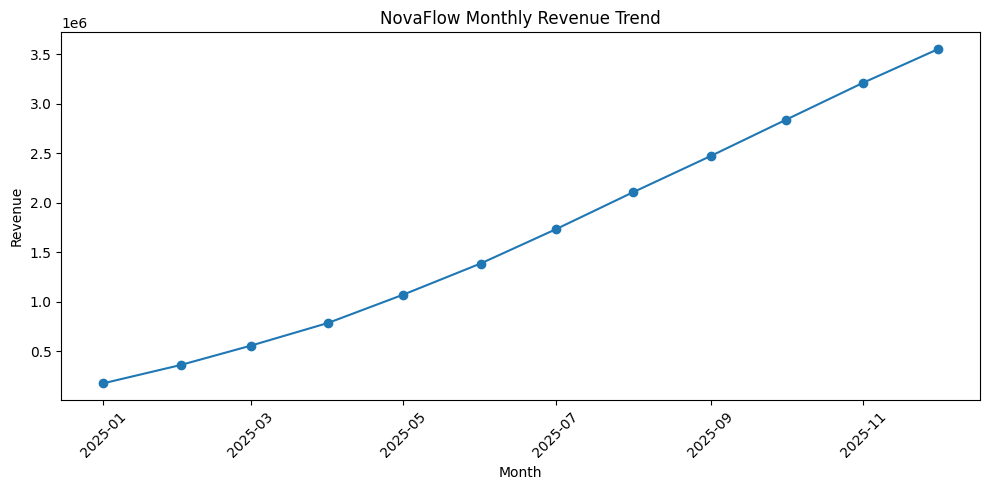

In [54]:
#Revenue Trend Chart
plt.figure(figsize=(10, 5))

plt.plot(
    revenue["Month"],
    revenue["Monthly Revenue"],
    marker="o")

plt.title("NovaFlow Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

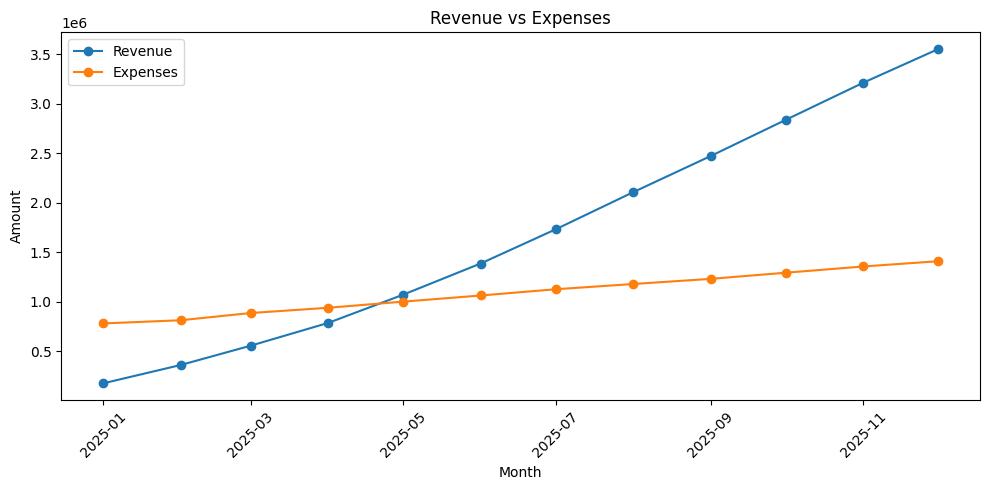

In [56]:
# Revenue vs Expenses
plt.figure(figsize=(10, 5))

plt.plot(revenue["Month"],
    revenue["Monthly Revenue"],
    marker="o",
    label="Revenue")

plt.plot( revenue["Month"],
    expenses["Total Expenses"],
    marker="o",
    label="Expenses")

plt.title("Revenue vs Expenses")
plt.xlabel("Month")
plt.ylabel("Amount")

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

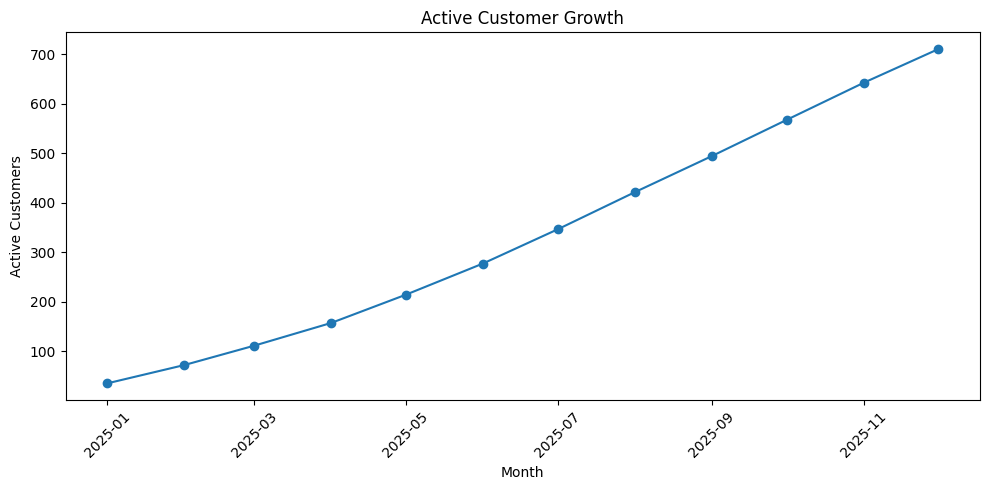

In [57]:
#CUSTOMER GROWTH 
plt.figure(figsize=(10, 5))

plt.plot(
    revenue["Month"],
    revenue["Active Customers"],
    marker="o")

plt.title("Active Customer Growth")
plt.xlabel("Month")
plt.ylabel("Active Customers")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

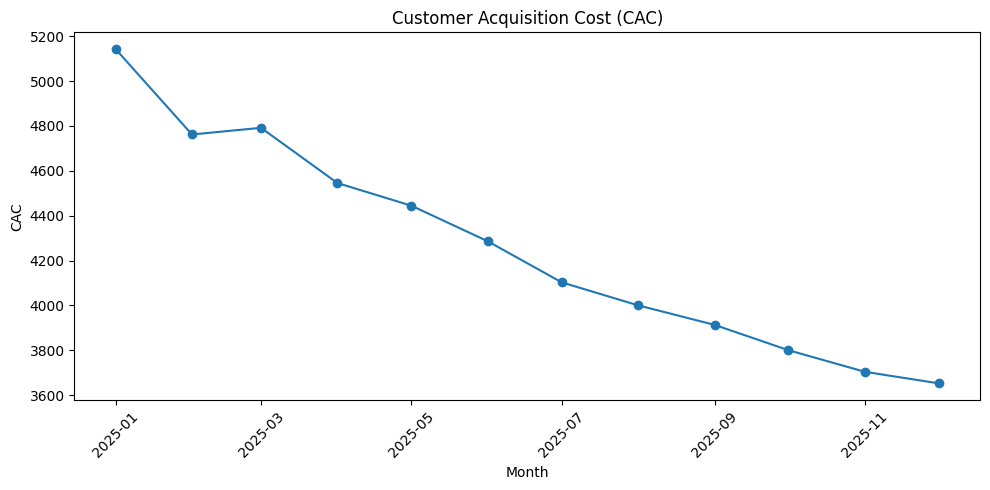

In [58]:
#CAC Trend
plt.figure(figsize=(10, 5))

plt.plot(
    revenue["Month"],
    revenue["CAC"],
    marker="o")

plt.title("Customer Acquisition Cost (CAC)")
plt.xlabel("Month")
plt.ylabel("CAC")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

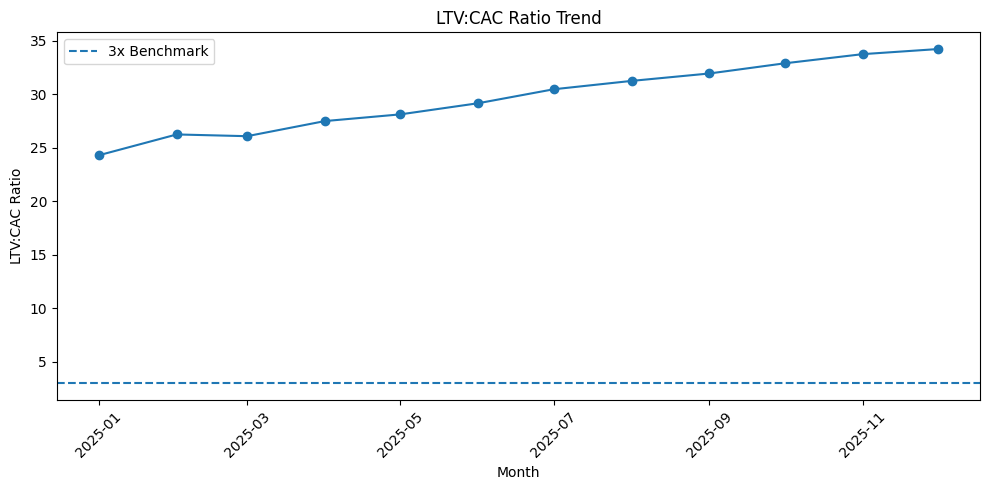

In [59]:
#LTV:CAC Trend
plt.figure(figsize=(10, 5))

plt.plot(
    revenue["Month"],
    revenue["LTV_CAC"],
    marker="o")

plt.axhline(
    y=3,
    linestyle="--",
    label="3x Benchmark")

plt.title("LTV:CAC Ratio Trend")
plt.xlabel("Month")
plt.ylabel("LTV:CAC Ratio")

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

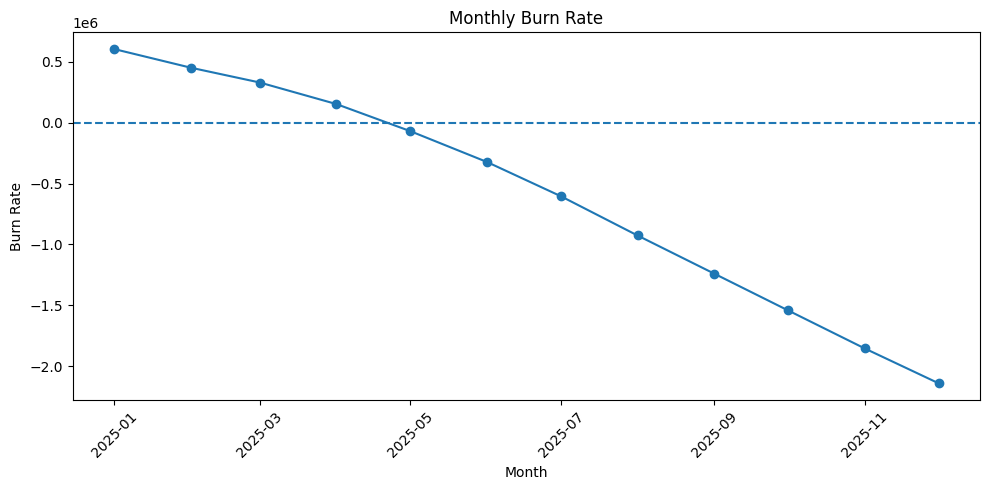

In [60]:
#Burn Rate Trend
plt.figure(figsize=(10, 5))

plt.plot(
    revenue["Month"],
    revenue["Burn_Rate"],
    marker="o")

plt.axhline(
    y=0,
    linestyle="--")

plt.title("Monthly Burn Rate")
plt.xlabel("Month")
plt.ylabel("Burn Rate")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [61]:
#COHORT ANALSYSIS
display(cohort)

,Cohort Month,Month 0,Month 1,Month 2,Month 3,Month 4,Month 5,Month 6,Month 7,Month 8,Month 9,Month 10,Month 11
0,2025-01-01,5,5,4,4,4,3,3,3,3,3,3,3
1,2025-02-01,5,5,5,4,4,4,3,3,3,3,3,3
2,2025-03-01,7,7,6,6,5,5,4,4,4,4,4,4
3,2025-04-01,8,8,7,7,6,6,5,5,5,5,5,5
4,2025-05-01,9,9,8,7,7,6,6,6,5,5,5,5
5,2025-06-01,10,10,9,8,8,7,7,6,6,6,6,6
6,2025-07-01,10,10,9,9,8,8,7,7,7,7,7,7
7,2025-08-01,11,11,10,9,9,8,8,8,7,7,7,7
8,2025-09-01,10,10,9,9,8,8,7,7,7,7,7,7
9,2025-10-01,9,9,8,8,7,7,6,6,6,6,6,6


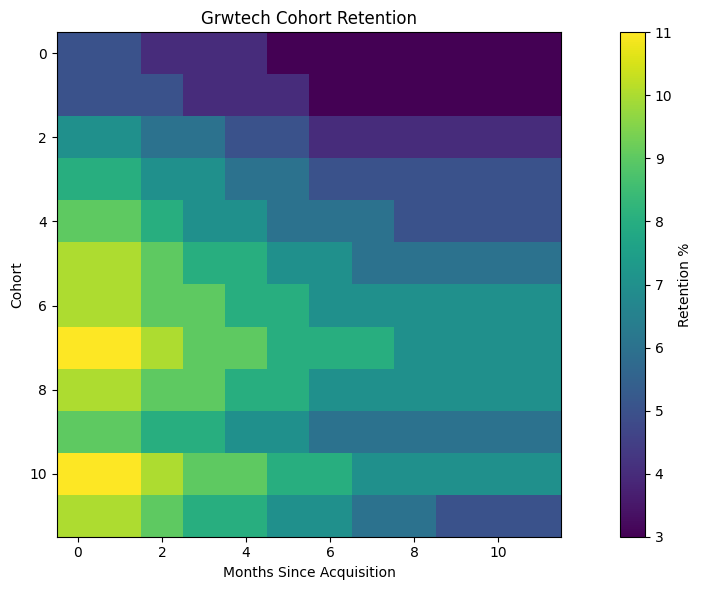

In [63]:
cohort_numeric = cohort.select_dtypes(include="number")

plt.figure(figsize=(12, 6))

plt.imshow(
    cohort_numeric
)

plt.colorbar(label="Retention %")

plt.title("Grwtech Cohort Retention")
plt.xlabel("Months Since Acquisition")
plt.ylabel("Cohort")

plt.tight_layout()
plt.show()

In [64]:
highest_revenue_month = revenue.loc[
    revenue["Monthly Revenue"].idxmax(),
    "Month"
]

highest_revenue = revenue["Monthly Revenue"].max()

lowest_cac_month = revenue.loc[
    revenue["CAC"].idxmin(),
    "Month"
]

lowest_cac = revenue["CAC"].min()

highest_ltv_cac_month = revenue.loc[
    revenue["LTV_CAC"].idxmax(),
    "Month"
]

highest_ltv_cac = revenue["LTV_CAC"].max()

highest_customer_month = revenue.loc[
    revenue["Active Customers"].idxmax(),
    "Month"
]

highest_customers = revenue["Active Customers"].max()

print("===== KEY BUSINESS INSIGHTS =====")

print(
    f"Highest monthly revenue: ₹{highest_revenue:,.0f} "
    f"in {highest_revenue_month}"
)

print(
    f"Lowest CAC: ₹{lowest_cac:,.2f} "
    f"in {lowest_cac_month}"
)

print(
    f"Highest LTV:CAC ratio: {highest_ltv_cac:.2f} "
    f"in {highest_ltv_cac_month}"
)

print(
    f"Highest active customer count: {highest_customers:,.0f} "
    f"in {highest_customer_month}"
)

===== KEY BUSINESS INSIGHTS =====
Highest monthly revenue: ₹3,550,000 in 2025-12-01 00:00:00
Lowest CAC: ₹3,652.17 in 2025-12-01 00:00:00
Highest LTV:CAC ratio: 34.23 in 2025-12-01 00:00:00
Highest active customer count: 710 in 2025-12-01 00:00:00


In [65]:
print("\n===== Grwtech 2025 FINANCIAL SUMMARY =====")

print(f"Annual Revenue: ₹{total_revenue:,.0f}")
print(f"Annual Expenses: ₹{total_expenses:,.0f}")
print(f"Annual Net Profit/Loss: ₹{annual_profit_loss:,.0f}")
print(f"Average CAC: ₹{average_cac:,.2f}")
print(f"Average LTV:CAC: {average_ltv_cac:.2f}")
print(f"December Run Rate: ₹{latest['Run_Rate']:,.0f}")


===== Grwtech 2025 FINANCIAL SUMMARY =====
Annual Revenue: ₹20,230,000
Annual Expenses: ₹13,065,000
Annual Net Profit/Loss: ₹7,165,000
Average CAC: ₹4,261.96
Average LTV:CAC: 29.66
December Run Rate: ₹42,600,000
